In [26]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import easygems.healpix as egh

from utils import hp_mods, plot_all_fields

import cartopy
import cartopy.mpl.geoaxes
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [3]:
# Open catalog and print hk26 available models.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [4]:
# Load specific model.
sim_ral3p3 = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat_ral3p3 = cat[sim_ral3p3]

sim_gal9 = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat_gal9 = cat[sim_gal9]

sim_CoM10 = 'um_glm_n1280_CoMA9_hk26'
sim_cat_CoM10 = cat[sim_CoM10]

sim_CoM5 = 'um_glm_n2560_CoMA9_hk26'
sim_cat_CoM5 = cat[sim_CoM5]

In [6]:
# Open a 1h (2D) and 3h (3D) dataset.
ds1h_ral3p3 = sim_cat_ral3p3(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
# ds3h = sim_cat(zoom=8, time='PT3H').to_dask().pipe(hp_mods)

ds1h_gal9 = sim_cat_gal9(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds1h_CoM10 = sim_cat_CoM10(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds1h_CoM5 = sim_cat_CoM5(zoom=8, time='PT1H').to_dask().pipe(hp_mods)

In [7]:
precip_ral3p3 = ds1h_ral3p3['pr']
aus_mask_ral3p3 = (ds1h_ral3p3.lon > 110) & (ds1h_ral3p3.lon < 160) & (ds1h_ral3p3.lat > -45) & (ds1h_ral3p3.lat < -5)
precip_aus_ral3p3 = precip_ral3p3.where(aus_mask_ral3p3)
precip_aus_ral3p3

<xarray.DataArray 'pr' (time: 9745, cell: 786432)> Size: 31GB
dask.array<where, shape=(9745, 786432), dtype=float32, chunksize=(16, 65536), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    crs      int64 8B 0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 4, 203]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['stratiform_rainfall_flux', 'stratiform_snowfall_flux']
    notes:          Combined rain and snow. Hourly mean - time index shifted ...
    grid_mapping:   crs

In [8]:
precip_gal9 = ds1h_gal9['pr']
aus_mask_gal9 = (ds1h_gal9.lon > 110) & (ds1h_gal9.lon < 160) & (ds1h_gal9.lat > -45) & (ds1h_gal9.lat < -5)
precip_aus_gal9 = precip_gal9.where(aus_mask_gal9)
precip_aus_gal9

<xarray.DataArray 'pr' (time: 9745, cell: 786432)> Size: 31GB
dask.array<where, shape=(9745, 786432), dtype=float32, chunksize=(16, 65536), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    crs      int64 8B 0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 5, 205]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['convective_rainfall_flux', 'convective_snowfall_flux', ...
    notes:          Combined rain and snow, convective and stratiform. Hourly...
    grid_mapping:   crs

In [9]:
precip_CoM10 = ds1h_CoM10['pr']
aus_mask_CoM10 = (ds1h_CoM10.lon > 110) & (ds1h_CoM10.lon < 160) & (ds1h_CoM10.lat > -45) & (ds1h_CoM10.lat < -5)
precip_aus_CoM10 = precip_CoM10.where(aus_mask_CoM10)
precip_aus_CoM10

<xarray.DataArray 'pr' (time: 9745, cell: 786432)> Size: 31GB
dask.array<where, shape=(9745, 786432), dtype=float32, chunksize=(16, 65536), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    crs      int64 8B 0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 5, 216]
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['precipitation_flux']
    notes:          Uses instantaneous total precipitation
    grid_mapping:   crs

In [10]:
precip_CoM5 = ds1h_CoM5['pr']
aus_mask_CoM5 = (ds1h_CoM5.lon > 110) & (ds1h_CoM5.lon < 160) & (ds1h_CoM5.lat > -45) & (ds1h_CoM5.lat < -5)
precip_aus_CoM5 = precip_CoM5.where(aus_mask_CoM5)
precip_aus_CoM5

<xarray.DataArray 'pr' (time: 9745, cell: 786432)> Size: 31GB
dask.array<where, shape=(9745, 786432), dtype=float32, chunksize=(16, 65536), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
    crs      int64 8B 0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 5, 216]
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['precipitation_flux']
    notes:          Uses instantaneous total precipitation
    grid_mapping:   crs

In [11]:
%%time
precip_aus_total_ral3p3 = precip_aus_ral3p3.mean('time').compute()
precip_aus_total_gal9 = precip_aus_gal9.mean('time').compute()
precip_aus_total_CoM10 = precip_aus_CoM10.mean('time').compute()
precip_aus_total_CoM5 = precip_aus_CoM5.mean('time').compute()

CPU times: user 2min 37s, sys: 39.5 s, total: 3min 17s
Wall time: 4min 47s


Text(0.5, 1.0, '5 km CoMA9')

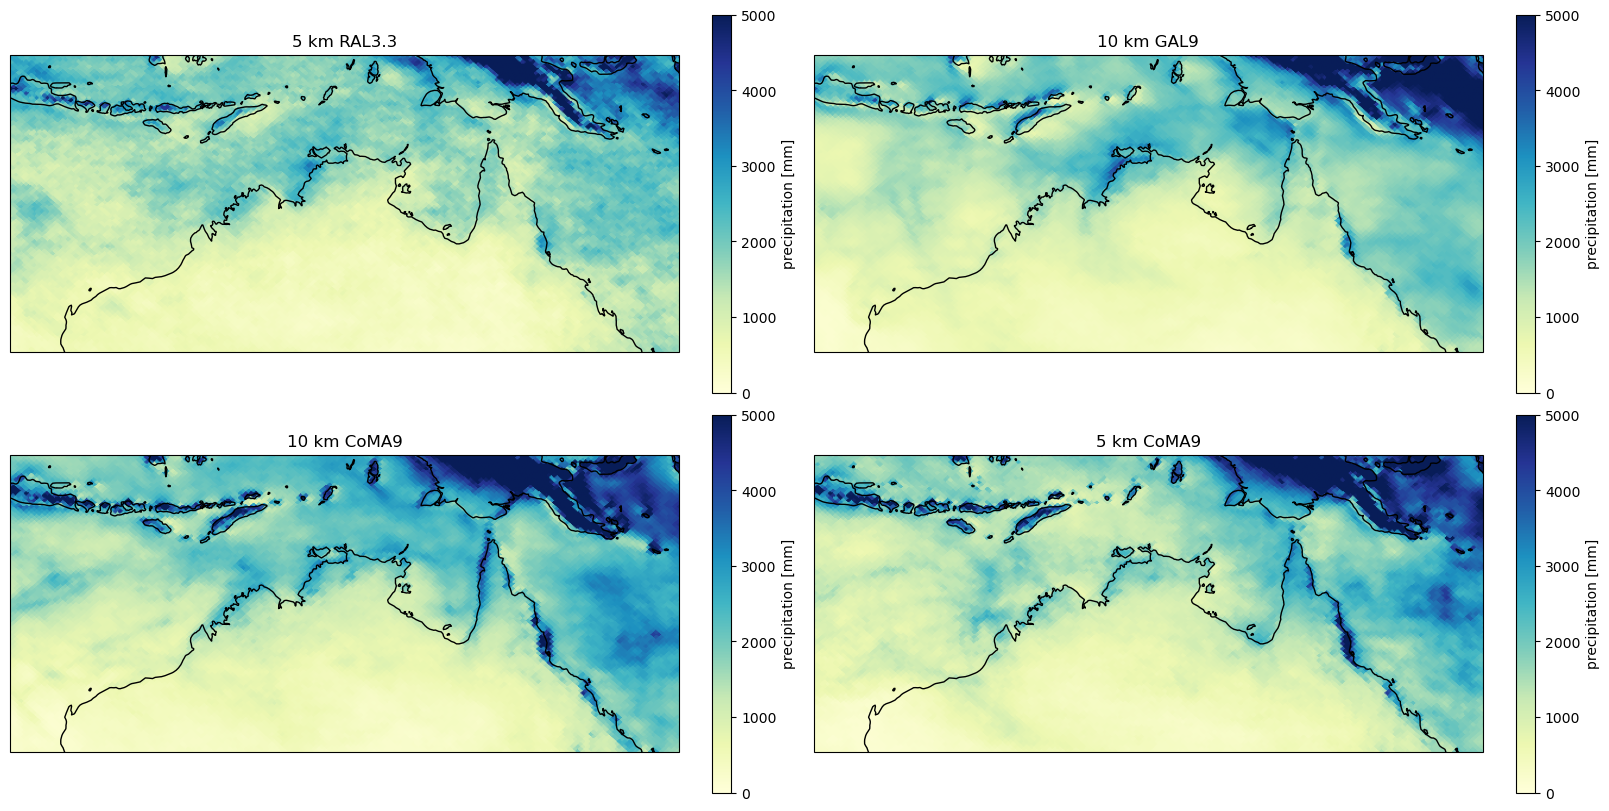

In [151]:
crs0 = projection=ccrs.PlateCarree(central_longitude=0)

fig, axs = plt.subplots(2, 2, subplot_kw={'projection':crs0}, layout='constrained', figsize=(16, 8))

ax = axs[0][0]
ax.set_extent((110, 155, -25, -5), crs=crs0)
ax.coastlines()
p1 = egh.healpix_show(precip_aus_total_ral3p3*60*60*24*365, ax=ax, vmin=0, vmax=5000, cmap='YlGnBu')
plt.colorbar(p1, label='precipitation [mm]')
ax.set_title('5 km RAL3.3')

ax = axs[0][1]
ax.set_extent((110, 155, -25, -5), crs=crs0)
ax.coastlines()
p1 = egh.healpix_show(precip_aus_total_gal9*60*60*24*365, ax=ax, vmin=0, vmax=5000, cmap='YlGnBu')
plt.colorbar(p1, label='precipitation [mm]')
ax.set_title('10 km GAL9')

ax = axs[1][0]
ax.set_extent((110, 155, -25, -5), crs=crs0)
ax.coastlines()
p1 = egh.healpix_show(precip_aus_total_CoM10*60*60*24*365, ax=ax, vmin=0, vmax=5000, cmap='YlGnBu')
plt.colorbar(p1, label='precipitation [mm]')
ax.set_title('10 km CoMA9')

ax = axs[1][1]
ax.set_extent((110, 155, -25, -5), crs=crs0)
ax.coastlines()
p1 = egh.healpix_show(precip_aus_total_CoM5*60*60*24*365, ax=ax, vmin=0, vmax=5000, cmap='YlGnBu')
plt.colorbar(p1, label='precipitation [mm]')
ax.set_title('5 km CoMA9')

### Time series of monsoon rainfall

In [21]:
def moving_average(data, n=24):
    data = xr.DataArray(data, dims = data.dims)#['time'])
    data = data.fillna(0)
    data = data.rolling(time=n, center=True).mean().dropna('time')
    return data

In [22]:
%%time

aus_mons_mask_ral3p3 = (ds1h_ral3p3.lon > 120) & (ds1h_ral3p3.lon < 150) & (ds1h_ral3p3.lat > -20) & (ds1h_ral3p3.lat < -10)
precip_aus_mons_ral3p3 = precip_ral3p3.where(aus_mons_mask_ral3p3)
precip_aus_mons_av_ral3p3 = precip_aus_mons_ral3p3.mean('cell').compute()
precip_aus_mons_av_daily_ral3p3 = precip_aus_mons_av_ral3p3.resample(time='1D').mean()
precip_aus_mons_av_45day_ral3p3 = moving_average(precip_aus_mons_av_daily_ral3p3, n=45)

CPU times: user 37.7 s, sys: 8.36 s, total: 46 s
Wall time: 1min 21s


In [23]:
%%time

aus_mons_mask_gal9 = (ds1h_gal9.lon > 120) & (ds1h_gal9.lon < 150) & (ds1h_gal9.lat > -20) & (ds1h_gal9.lat < -10)
precip_aus_mons_gal9 = precip_gal9.where(aus_mons_mask_gal9)
precip_aus_mons_av_gal9 = precip_aus_mons_gal9.mean('cell').compute()
precip_aus_mons_av_daily_gal9 = precip_aus_mons_av_gal9.resample(time='1D').mean()
precip_aus_mons_av_45day_gal9 = moving_average(precip_aus_mons_av_daily_gal9, n=45)

CPU times: user 38.2 s, sys: 10 s, total: 48.3 s
Wall time: 1min 24s


In [24]:
%%time

aus_mons_mask_CoM10 = (ds1h_CoM10.lon > 120) & (ds1h_CoM10.lon < 150) & (ds1h_CoM10.lat > -20) & (ds1h_CoM10.lat < -10)
precip_aus_mons_CoM10 = precip_CoM10.where(aus_mons_mask_CoM10)
precip_aus_mons_av_CoM10 = precip_aus_mons_CoM10.mean('cell').compute()
precip_aus_mons_av_daily_CoM10 = precip_aus_mons_av_CoM10.resample(time='1D').mean()
precip_aus_mons_av_45day_CoM10 = moving_average(precip_aus_mons_av_daily_CoM10, n=45)

CPU times: user 39.2 s, sys: 9.18 s, total: 48.4 s
Wall time: 1min 18s


In [25]:
%%time

aus_mons_mask_CoM5 = (ds1h_CoM5.lon > 120) & (ds1h_CoM5.lon < 150) & (ds1h_CoM5.lat > -20) & (ds1h_CoM5.lat < -10)
precip_aus_mons_CoM5 = precip_CoM5.where(aus_mons_mask_CoM5)
precip_aus_mons_av_CoM5 = precip_aus_mons_CoM5.mean('cell').compute()
precip_aus_mons_av_daily_CoM5 = precip_aus_mons_av_CoM5.resample(time='1D').mean()
precip_aus_mons_av_45day_CoM5 = moving_average(precip_aus_mons_av_daily_CoM5, n=45)

CPU times: user 39.3 s, sys: 10.2 s, total: 49.5 s
Wall time: 1min 18s


### Finding dates for monsoon bursts

This is roughly based on the method or Berry and Reeder (2016) where there is a transition from dry to wet within 7 days

In [136]:
def find_burst_dates(precip, precip_clim):
    """
    Find dates for monsoon bursts
    defined as going from lower to upper bound in less than 7 days
    """

    # precip_clim is smoothed and has less days so broadcast them
    precip, precip_clim = xr.align(precip, precip_clim)

    low_bound = precip_clim * 0.75
    high_bound = precip_clim * 1.25

    low_precip_days = precip < low_bound
    high_precip_days = precip > high_bound

    # first day of "high precip". Goes from False (0) to True (1) so diff is 1
    start_days = (high_precip_days.astype(int).diff('time') == 1)
    start_day_indices = start_days.values.nonzero()[0]

    # first day of "low precip"
    end_days = (low_precip_days.astype(int).diff('time') == 1)
    end_day_indices = end_days.values.nonzero()[0]

    burst_starts = []
    burst_lengths = []

    # for each high_precip_starts day, was rainfall below average at all in the last 7 days?
    # if so it is a monsoon burst, if not then it isn't
    for day in start_day_indices:
        
    # don't count anything in the first 7 days
        if day < 7:
            pass
            
        prev_7days = precip[day-7:day]
        if (prev_7days < low_bound).any():

            # also, there cannot be any bursts in the last 7 days (this would be an extension of the previous burst)
            if not start_days[day-7:day].any():
            
                burst_starts.append(day)

                # if we have found a burst day, calculate its length
                # this is defined when it drops back down
                # find the first day in end_day indices above day

                burst_end = end_day_indices[(end_day_indices > day).argmax()]
                #print(day, burst_end)
                burst_length = burst_end - day
                burst_length = max(burst_length, 0)# remove weird negative values
                burst_lengths.append(burst_length)
    
    return np.array(burst_starts), np.array(burst_lengths)

In [137]:
burst_starts_gal9, burst_lengths_gal9 = find_burst_dates(precip_aus_mons_av_daily_gal9, precip_aus_mons_av_45day_gal9)
burst_starts_ral3p3, burst_lengths_ral3p3 = find_burst_dates(precip_aus_mons_av_daily_ral3p3, precip_aus_mons_av_45day_ral3p3)
burst_starts_CoM10, burst_lengths_CoM10 = find_burst_dates(precip_aus_mons_av_daily_CoM10, precip_aus_mons_av_45day_CoM10)
burst_starts_CoM5, burst_lengths_CoM5 = find_burst_dates(precip_aus_mons_av_daily_CoM5, precip_aus_mons_av_45day_CoM5)

[  7  20  25  38  74  82  96 125 144 149 154 169 175 187 192 207 216 219
 241 245 271 276 287 291 302 327 344 351 358]
[ 14  39  61  65  75  90 111 137 142 153 184 190 226 233 249 263 275 280
 285 287 289 302 308 312 321 340 349]
[  1  26  29  37  50  80 100 110 123 138 140 145 153 167 172 179 183 211
 218 224 245 250 252 257 261 266 269 291 308 311 319 328 337 355 360]
[  8  12  14  25  33  39  49  75  92 108 113 125 134 149 157 162 169 171
 173 177 195 202 219 221 244 249 255 275 294 301 304 307 313 331 336 339
 346 356]


In [143]:
precip_aus_mons_av_45day_ral3p3['time'][i + burst_lengths_ral3p3[i]].values

np.datetime64('2020-02-25T00:00:00.000000000')

/tmp/ipykernel_1975/114156956.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1975/114156956.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1975/114156956.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


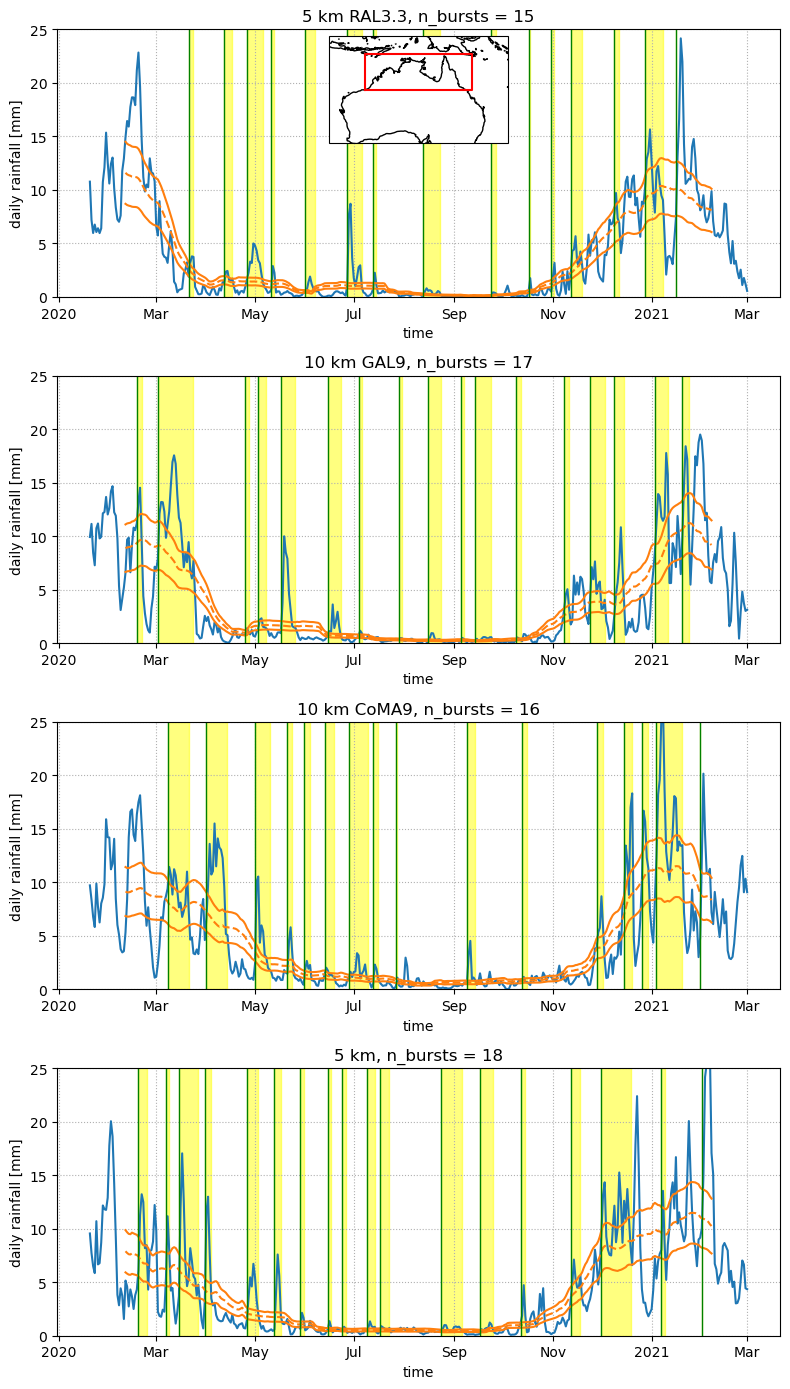

In [149]:
plt.figure(figsize=(8,14))

ax = plt.subplot(411)
(precip_aus_mons_av_daily_ral3p3*60*60*24).plot()
(precip_aus_mons_av_45day_ral3p3 *60*60*24).plot(ls='--')
(precip_aus_mons_av_45day_ral3p3 * 0.75 *60*60*24).plot(c='tab:orange', ls='-')
(precip_aus_mons_av_45day_ral3p3 * 1.25 *60*60*24).plot(c='tab:orange', ls='-')
for i, t in enumerate(burst_starts_ral3p3):
    plt.axvline(precip_aus_mons_av_45day_ral3p3['time'][t].values, c='g', ls='-', lw=1)
    plt.axvspan(precip_aus_mons_av_45day_ral3p3['time'][t].values, precip_aus_mons_av_45day_ral3p3['time'][t + burst_lengths_ral3p3[i]].values, alpha=0.5, color='yellow')
plt.grid(ls=':')
plt.ylabel('daily rainfall [mm]')
plt.title(f'5 km RAL3.3, n_bursts = {burst_starts_ral3p3.size}')
plt.ylim(0, 25)


axins = inset_axes(ax, width="40%", height="40%", loc="upper center", 
                   axes_class=cartopy.mpl.geoaxes.GeoAxes, 
                   axes_kwargs=dict(projection=cartopy.crs.PlateCarree()))
axins.add_feature(cartopy.feature.COASTLINE)
axins.set_extent((110, 160, -35, -5), crs=crs0)
plt.plot([120, 150, 150, 120, 120], [-20, -20, -10, -10, -20], c='r')


plt.subplot(412)
(precip_aus_mons_av_daily_gal9*60*60*24).plot()
(precip_aus_mons_av_45day_gal9 *60*60*24).plot(ls='--')
(precip_aus_mons_av_45day_gal9 * 0.75 *60*60*24).plot(c='tab:orange', ls='-')
(precip_aus_mons_av_45day_gal9 * 1.25 *60*60*24).plot(c='tab:orange', ls='-')
for i, t in enumerate(burst_starts_gal9):
    plt.axvline(precip_aus_mons_av_45day_gal9['time'][t].values, c='g', ls='-', lw=1)
    plt.axvspan(precip_aus_mons_av_45day_gal9['time'][t].values, precip_aus_mons_av_45day_gal9['time'][t + burst_lengths_gal9[i]].values, alpha=0.5, color='yellow')
plt.grid(ls=':')
plt.ylabel('daily rainfall [mm]')
plt.title(f'10 km GAL9, n_bursts = {burst_starts_gal9.size}')
plt.ylim(0, 25)

plt.tight_layout()


plt.subplot(413)
(precip_aus_mons_av_daily_CoM10*60*60*24).plot()
(precip_aus_mons_av_45day_CoM10 *60*60*24).plot(ls='--')
(precip_aus_mons_av_45day_CoM10 * 0.75 *60*60*24).plot(c='tab:orange', ls='-')
(precip_aus_mons_av_45day_CoM10 * 1.25 *60*60*24).plot(c='tab:orange', ls='-')
for i, t in enumerate(burst_starts_CoM10):
    plt.axvline(precip_aus_mons_av_45day_CoM10['time'][t].values, c='g', ls='-', lw=1)
    plt.axvspan(precip_aus_mons_av_45day_CoM10['time'][t].values, precip_aus_mons_av_45day_CoM10['time'][t + burst_lengths_CoM10[i]].values, alpha=0.5, color='yellow')
plt.grid(ls=':')
plt.ylabel('daily rainfall [mm]')
plt.title(f'10 km CoMA9, n_bursts = {burst_starts_CoM10.size}')
plt.ylim(0, 25)

plt.tight_layout()


plt.subplot(414)
(precip_aus_mons_av_daily_CoM5*60*60*24).plot()
(precip_aus_mons_av_45day_CoM5 *60*60 * 24).plot(ls='--')
(precip_aus_mons_av_45day_CoM5 * 0.75 *60*60*24).plot(c='tab:orange', ls='-')
(precip_aus_mons_av_45day_CoM5 * 1.25 *60*60*24).plot(c='tab:orange', ls='-')
for i, t in enumerate(burst_starts_CoM5):
    plt.axvline(precip_aus_mons_av_45day_CoM5['time'][t].values, c='g', ls='-', lw=1)
    plt.axvspan(precip_aus_mons_av_45day_CoM5['time'][t].values, precip_aus_mons_av_45day_CoM5['time'][t + burst_lengths_CoM5[i]].values, alpha=0.5, color='yellow')
plt.grid(ls=':')
plt.ylabel('daily rainfall [mm]')
plt.title(f'5 km, n_bursts = {burst_starts_CoM5.size}')
plt.ylim(0, 25)

plt.tight_layout()

